<a href="https://colab.research.google.com/github/bogiereddy/machine-learning_practice/blob/main/knn_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
iris= load_iris()

In [2]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [3]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df.shape

(150, 4)

In [14]:
df['target'].head()
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target==1,target==0
0,5.1,3.5,1.4,0.2,0,0,0
1,4.9,3.0,1.4,0.2,0,0,0
2,4.7,3.2,1.3,0.2,0,0,0
3,4.6,3.1,1.5,0.2,0,0,0
4,5.0,3.6,1.4,0.2,0,0,0


In [12]:
df[df.target==1].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target==1,target==0
50,7.0,3.2,4.7,1.4,1,1,1
51,6.4,3.2,4.5,1.5,1,1,1
52,6.9,3.1,4.9,1.5,1,1,1
53,5.5,2.3,4.0,1.3,1,1,1
54,6.5,2.8,4.6,1.5,1,1,1


In [13]:
df[df.target==2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target==1,target==0
100,6.3,3.3,6.0,2.5,2,2,2
101,5.8,2.7,5.1,1.9,2,2,2
102,7.1,3.0,5.9,2.1,2,2,2
103,6.3,2.9,5.6,1.8,2,2,2
104,6.5,3.0,5.8,2.2,2,2,2


In [15]:
df['flower_name']= df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target==1,target==0,flower_name
0,5.1,3.5,1.4,0.2,0,0,0,setosa
1,4.9,3.0,1.4,0.2,0,0,0,setosa
2,4.7,3.2,1.3,0.2,0,0,0,setosa
3,4.6,3.1,1.5,0.2,0,0,0,setosa
4,5.0,3.6,1.4,0.2,0,0,0,setosa


In [16]:
df0=df[:50]
df1=df[50:100]
df2=df[100:]

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

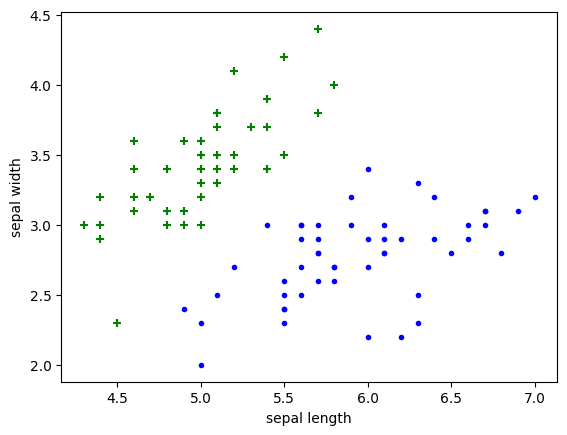

In [22]:
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.scatter(df0['sepal length (cm)'], df0['sepal width (cm)'], color='green', marker='+')
plt.scatter(df1['sepal length (cm)'], df1['sepal width (cm)'], color='blue', marker='.')


In [26]:
from sklearn.model_selection import train_test_split
X=df.drop( ['target','flower_name'],axis='columns')
y=df.target
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=1)

In [27]:
len(X_train)

120

In [28]:
len(X_test)

30

In [32]:
##knn
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train,y_train)
knn.score(X_test,y_test)

1.0

In [33]:
from sklearn.metrics import confusion_matrix
y_pred=knn.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
cm

array([[11,  0,  0],
       [ 0, 13,  0],
       [ 0,  0,  6]])

Text(95.72222222222221, 0.5, 'Truth')

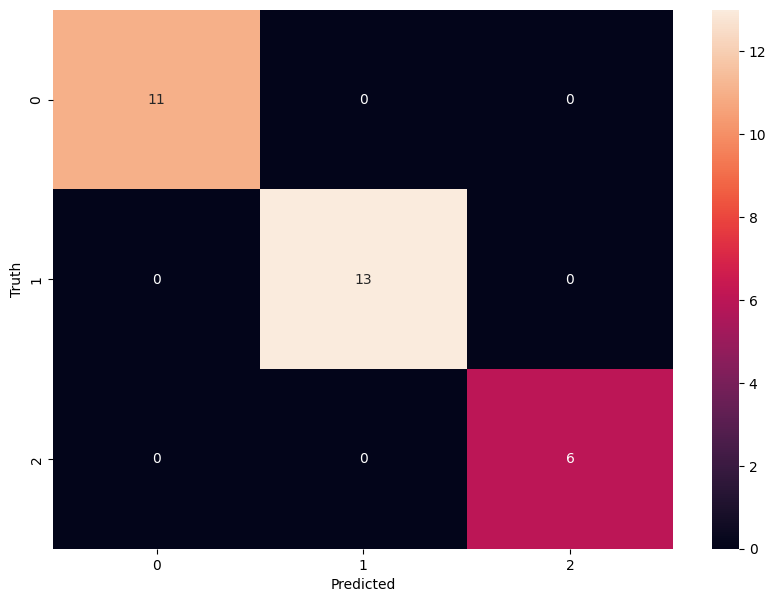

In [35]:
%matplotlib inline
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

